# Feature Engineering: A Comprehensive Guide

Feature Engineering is the process of using domain knowledge and data manipulation to create, transform, or select features (input variables) that improve model performance. It is often described as more art than science and is one of the most impactful things you can do in ML.

In this notebook, we'll cover:
1. Feature Creation (polynomial, interaction features, date features)
2. Feature Transformation (log, sqrt, Box-Cox, scaling)
3. Feature Encoding (one-hot, label, ordinal, target encoding)
4. Feature Selection (filter, wrapper, embedded methods)
5. Handling Missing Values

# Simple Explanation: What Does the Code Below Do?

Imagine building a house value predictor. The raw data says a house has 2000 sq ft and 3 bedrooms. But you realize that price/sq ft is more informative than raw sq ft. Creating this ratio is Feature Engineering!

Why is Feature Engineering important?
- Better features → Better models, even with simple algorithms.
- It reduces the burden on the model to discover relationships in the data.
- 'Garbage in, garbage out' — poor features lead to poor models.

Key techniques:
- **Scaling**: Standardize features to similar ranges.
- **Encoding**: Convert categorical variables to numbers.
- **Transformation**: Log or sqrt to handle skewed distributions.
- **Interaction features**: Combine two features to capture relationships.
- **Feature selection**: Remove irrelevant or redundant features.

Here's what the code does:
1. Demonstrates each technique step by step.
2. Shows the impact of feature engineering on model performance.
3. Covers missing value handling strategies.

In short: Feature engineering transforms raw data into information a model can learn from effectively!

In [1]:
import os
import sys

venv_dir = 'ml_env'
if not os.path.exists(venv_dir):
    os.system(f'{sys.executable} -m venv {venv_dir}')
    print(f'Virtual environment created at {venv_dir}')
else:
    print(f'Virtual environment already exists at {venv_dir}')

pip_path = os.path.join(venv_dir, 'Scripts', 'pip')
if sys.platform == 'win32':
    pip_path += '.exe'

if os.path.exists(pip_path):
    os.system(f'"{pip_path}" install numpy pandas matplotlib seaborn scikit-learn scipy')
    print('Required libraries installed.')
else:
    print('Could not find pip. Please check your Python installation.')

Virtual environment already exists at ml_env
Required libraries installed.


# 1. Required Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import (StandardScaler, MinMaxScaler, RobustScaler, 
                                    LabelEncoder, OneHotEncoder, PolynomialFeatures,
                                    PowerTransformer)
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif, RFE
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.datasets import load_breast_cancer
from scipy import stats

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# 2. Feature Scaling

Many algorithms (SVM, KNN, Neural Networks, Logistic Regression) are sensitive to feature magnitude. Scaling ensures all features contribute equally.

- **StandardScaler**: Zero mean, unit variance. Best for normally distributed data.
- **MinMaxScaler**: Scales to [0, 1]. Best when you need bounded values.
- **RobustScaler**: Uses IQR, robust to outliers.

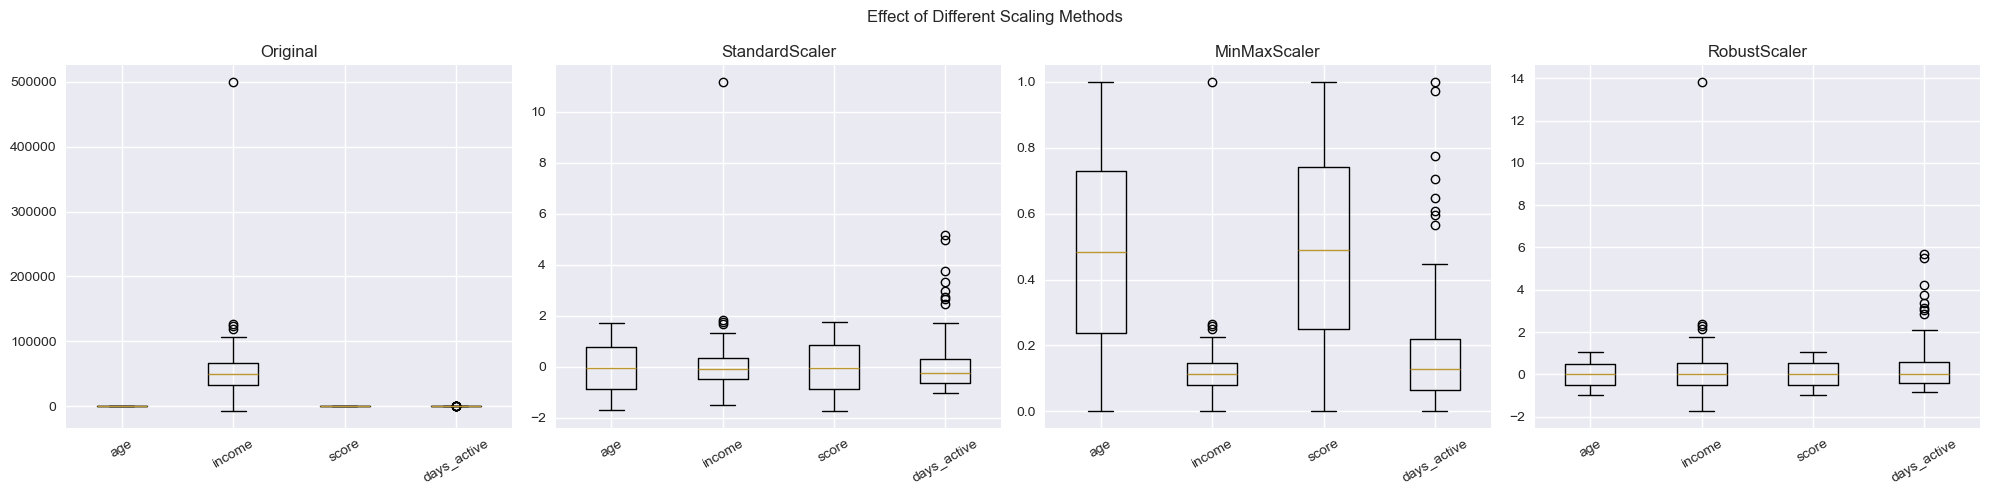

Scale comparison after scaling:
  StandardScaler      : range = [-1.74, 11.16], std = 1.00
  MinMaxScaler        : range = [0.00, 1.00], std = 0.29
  RobustScaler        : range = [-1.75, 13.83], std = 0.92


In [3]:
# Create a dataset with features on very different scales
np.random.seed(42)
n = 200
raw_data = pd.DataFrame({
    'age': np.random.randint(20, 80, n),
    'income': np.random.normal(50000, 25000, n),
    'score': np.random.uniform(0, 100, n),
    'days_active': np.random.exponential(30, n)
})

# Add an outlier
raw_data.loc[0, 'income'] = 500000

scalers = {
    'Original': None,
    'StandardScaler': StandardScaler(),
    'MinMaxScaler': MinMaxScaler(),
    'RobustScaler': RobustScaler()
}

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, (name, scaler) in zip(axes, scalers.items()):
    if scaler is None:
        data_plot = raw_data.values
    else:
        data_plot = scaler.fit_transform(raw_data)
    ax.boxplot(data_plot, labels=raw_data.columns, vert=True)
    ax.set_title(name)
    ax.tick_params(axis='x', rotation=30)
    ax.grid(True, axis='y')

plt.suptitle('Effect of Different Scaling Methods')
plt.tight_layout()
plt.show()

print('Scale comparison after scaling:')
for name, scaler in scalers.items():
    if scaler is not None:
        d = scaler.fit_transform(raw_data)
        print(f'  {name:<20}: range = [{d.min():.2f}, {d.max():.2f}], std = {d.std():.2f}')

# 3. Feature Encoding for Categorical Variables

In [4]:
# Sample categorical dataset
cat_df = pd.DataFrame({
    'color': ['red', 'blue', 'green', 'red', 'blue', 'green', 'red'],
    'size': ['small', 'medium', 'large', 'medium', 'small', 'large', 'medium'],
    'quality': ['low', 'medium', 'high', 'high', 'medium', 'low', 'high'],
    'target': [1, 0, 1, 1, 0, 1, 1]
})

print('Original Data:')
print(cat_df)

# 1. One-Hot Encoding (for nominal, unordered categories)
color_ohe = pd.get_dummies(cat_df['color'], prefix='color')
print('\nOne-Hot Encoding (color):')
print(color_ohe)

# 2. Label Encoding (for binary or ordinal categories)
le = LabelEncoder()
cat_df['color_label'] = le.fit_transform(cat_df['color'])
print('\nLabel Encoding (color):')
print(cat_df[['color', 'color_label']])

# 3. Ordinal Encoding (for ordered categories)
size_order = {'small': 0, 'medium': 1, 'large': 2}
quality_order = {'low': 0, 'medium': 1, 'high': 2}
cat_df['size_ordinal'] = cat_df['size'].map(size_order)
cat_df['quality_ordinal'] = cat_df['quality'].map(quality_order)
print('\nOrdinal Encoding (size, quality):')
print(cat_df[['size', 'size_ordinal', 'quality', 'quality_ordinal']])

# 4. Target Encoding
target_mean = cat_df.groupby('color')['target'].mean()
cat_df['color_target_enc'] = cat_df['color'].map(target_mean)
print('\nTarget Encoding (color):')
print(cat_df[['color', 'target', 'color_target_enc']])

Original Data:
   color    size quality  target
0    red   small     low       1
1   blue  medium  medium       0
2  green   large    high       1
3    red  medium    high       1
4   blue   small  medium       0
5  green   large     low       1
6    red  medium    high       1

One-Hot Encoding (color):
   color_blue  color_green  color_red
0       False        False       True
1        True        False      False
2       False         True      False
3       False        False       True
4        True        False      False
5       False         True      False
6       False        False       True

Label Encoding (color):
   color  color_label
0    red            2
1   blue            0
2  green            1
3    red            2
4   blue            0
5  green            1
6    red            2

Ordinal Encoding (size, quality):
     size  size_ordinal quality  quality_ordinal
0   small             0     low                0
1  medium             1  medium                1
2   lar

# 4. Feature Transformation and Feature Selection

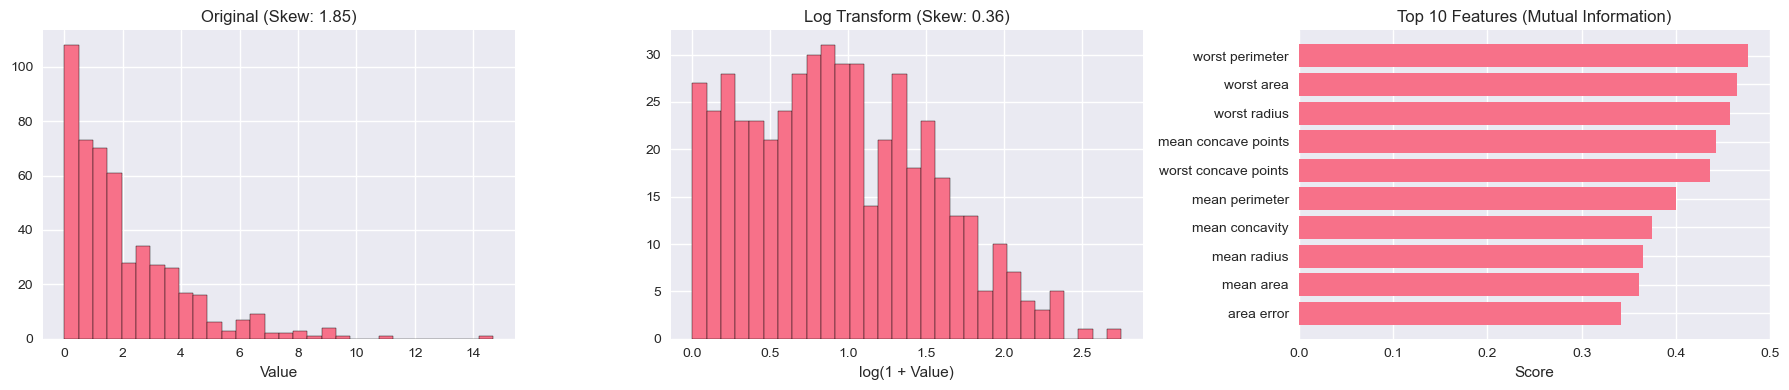

In [5]:
# Log transformation for skewed features
skewed_data = np.random.exponential(scale=2, size=500)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].hist(skewed_data, bins=30, edgecolor='k')
axes[0].set_title(f'Original (Skew: {stats.skew(skewed_data):.2f})')
axes[0].set_xlabel('Value')

log_data = np.log1p(skewed_data)
axes[1].hist(log_data, bins=30, edgecolor='k')
axes[1].set_title(f'Log Transform (Skew: {stats.skew(log_data):.2f})')
axes[1].set_xlabel('log(1 + Value)')

# Feature selection using cancer dataset
cancer = load_breast_cancer()
X_cancer, y_cancer = cancer.data, cancer.target

# SelectKBest with mutual information
selector = SelectKBest(score_func=mutual_info_classif, k=10)
selector.fit(X_cancer, y_cancer)
scores = selector.scores_
feature_names = cancer.feature_names

top_idx = np.argsort(scores)[-10:]
axes[2].barh(range(10), scores[top_idx])
axes[2].set_yticks(range(10))
axes[2].set_yticklabels([feature_names[i] for i in top_idx])
axes[2].set_title('Top 10 Features (Mutual Information)')
axes[2].set_xlabel('Score')

plt.tight_layout()
plt.show()

# 5. Handling Missing Values

In [6]:
# Create dataset with missing values
np.random.seed(42)
df_missing = pd.DataFrame(np.random.randn(100, 4), columns=['A', 'B', 'C', 'D'])
df_missing.iloc[5:10, 0] = np.nan     # 5% missing in A
df_missing.iloc[15:30, 1] = np.nan    # 15% missing in B
df_missing.iloc[50:70, 2] = np.nan    # 20% missing in C

print('Missing Values:')
print(df_missing.isnull().sum())
print(f'\nTotal missing: {df_missing.isnull().sum().sum()} out of {df_missing.size}')

# Strategy comparison
strategies = {
    'Mean Imputation': SimpleImputer(strategy='mean'),
    'Median Imputation': SimpleImputer(strategy='median'),
    'Most Frequent': SimpleImputer(strategy='most_frequent'),
    'KNN Imputation': KNNImputer(n_neighbors=5),
}

print('\nMean column B after imputation:')
original_mean = df_missing['B'].mean()
print(f'  Original (non-missing): {original_mean:.4f}')
for name, imputer in strategies.items():
    filled = imputer.fit_transform(df_missing)
    filled_df = pd.DataFrame(filled, columns=df_missing.columns)
    print(f'  {name:<22}: {filled_df["B"].mean():.4f}')

print('\nKey Engineering Insights:')
print('- Always scale features before SVM, KNN, and Neural Networks.')
print('- Use One-Hot encoding for nominal categories, Ordinal for ordered.')
print('- Log transform right-skewed features to improve model fit.')
print('- KNN imputation preserves relationships between features best.')
print('- Add an "is_missing" binary indicator feature when imputing.')

Missing Values:
A     5
B    15
C    20
D     0
dtype: int64

Total missing: 40 out of 400

Mean column B after imputation:
  Original (non-missing): 0.0009
  Mean Imputation       : 0.0009
  Median Imputation     : 0.0023
  Most Frequent         : -0.2932
  KNN Imputation        : 0.0100

Key Engineering Insights:
- Always scale features before SVM, KNN, and Neural Networks.
- Use One-Hot encoding for nominal categories, Ordinal for ordered.
- Log transform right-skewed features to improve model fit.
- KNN imputation preserves relationships between features best.
- Add an "is_missing" binary indicator feature when imputing.


# Conclusions and Key Takeaways
Feature engineering is the process of using domain knowledge to extract robust features from raw data. These features should improve the predictive power of machine learning algorithms.
- Better features often yield better results than more complex algorithms.
- Common techniques include imputation, encoding categorical variables, scaling, binning, and polynomial features.
- Dimensionality reduction and feature selection are important steps to refine the final feature set.

# Pros and Cons
**Pros:**
- Can drastically improve model accuracy and interpretability.
- Helps algorithms converge faster (e.g., scaling in gradient descent).
- Handles non-numerical data like text or dates by converting them to formats algorithms understand.

**Cons:**
- Very time-consuming; often the most labor-intensive part of ML.
- Requires strong domain knowledge to do correctly.
- Over-engineering can lead to data leakage or overfitting.

# 15 Interview Questions and Answers

1. **What is feature engineering?**
   *Answer*: The process of transforming raw data into features that better represent the underlying problem to the predictive models, resulting in improved model accuracy on unseen data.

2. **Why is feature engineering sometimes seen as more important than model tuning?**
   *Answer*: A simple model with excellent, highly discriminative features will generally outperform a complex, perfectly tuned model trained on poor quality or noisy features. "Garbage in, garbage out".

3. **What is One-Hot Encoding?**
   *Answer*: A process for converting categorical data into a binary matrix format. For a category with N unique values, it creates N new binary columns.

4. **What is the "Dummy Variable Trap" and how do you avoid it?**
   *Answer*: It occurs when one-hot encoded variables are highly correlated (multicollinear). For example, if gender is M or F, the columns are perfectly inversely correlated. To avoid it, one column is dropped (e.g., keeping N-1 columns).

5. **What is Target Encoding (Mean Encoding)?**
   *Answer*: Replacing categorical values with the mean of the target variable for that category. It is useful for high-cardinality features but prone to overfitting.

6. **How do you handle missing values?**
   *Answer*: Techniques include dropping the rows/columns (if minimal), imputing with mean/median/mode, using k-NN imputation, or predicting the missing values using another model.

7. **What is the difference between Normalization (Min-Max Scaling) and Standardization?**
   *Answer*: Normalization scales the values linearly to a 0-1 range. Standardization centers the data around a mean of 0 with a standard deviation of 1.

8. **When would you use Normalization vs. Standardization?**
   *Answer*: Normalization is useful when the algorithm expects input bounded to a specific range (like Neural Networks or distance-based algorithms like k-NN when features don't have bell-curve distribution). Standardization is better when the data follows a Gaussian distribution or for algorithms like PCA, Logistic Regression, and SVMs.

9. **What are polynomial features?**
   *Answer*: Features created by raising existing features to a power or multiplying them together (interaction terms). They help linear models capture non-linear relationships.

10. **What is Feature Selection?**
    *Answer*: The process of selecting a subset of relevant features for use in model construction to prevent overfitting, reduce training time, and improve accuracy.

11. **Name three common feature selection techniques.**
    *Answer*: Filter methods (e.g., correlation matrix), Wrapper methods (e.g., Recursive Feature Elimination), and Embedded methods (e.g., L1 Lasso regularization).

12. **What is data leakage?**
    *Answer*: When information from outside the training dataset is used to create the model, leading to overly optimistic performance during validation but failure in production. Example: using future data to engineer a feature.

13. **How do you engineer dates?**
    *Answer*: Extracting components like year, month, day of week, hour, or calculating differences between dates (e.g., days since last purchase). Sometimes circular encoding (sine/cosine) is used for time.

14. **What is binning or discretization?**
    *Answer*: Converting a continuous feature into multiple categorical bins. This can help models deal with extreme outliers and capture non-linear relationships.

15. **What is TF-IDF in the context of text feature engineering?**
    *Answer*: Term Frequency-Inverse Document Frequency. It evaluates how relevant a word is to a document in a collection. It increases proportionally to the number of times a word appears in the document but is offset by the global frequency of the word.
